<a href="https://colab.research.google.com/github/NehaMusale11/Machine-Vision/blob/main/Practical_08_MachineV_CM23057_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zoya77/warehouse-delivery-box-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 823M/823M [00:08<00:00, 107MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "zoya77/warehouse-delivery-box-detection-dataset"
)

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2


In [3]:
import os

print("Dataset path:")
print(path)

print("\nFiles and folders:")

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}  {file}")

    if level > 3:
        dirs[:] = []

Dataset path:
/root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2

Files and folders:
2/
  Box Dataset/
    valid/
      labels/
        r-319-_JPG_jpg.rf.66d11dc1535312a916a969dc0e17eabf.txt
        r-42-_JPG_jpg.rf.1cb0f43af51ee5ce7bb4e2d790f6c65a.txt
        180_flight_413_5216_png.rf.95a55132ff4bf500937dbc4b7205d96b.txt
        r-406-_JPG_jpg.rf.7c90a1cf1b32584693caf2d38816c5e2.txt
        158_flight_1625_4328_png.rf.c7fb41b04b51063be72ea1fb307a7eaf.txt
        159_flight_1664_359_png.rf.9c602c18a0f9c3531260986476184266.txt
        161_flight_1667_1205_png.rf.4e8c98affae618a754fd05136a892848.txt
        r-395-_JPG_jpg.rf.81946dded073aad92fb699e3e4535df8.txt
        180_flight_407_5154_png.rf.7525772f731dac972e1dae8187101db2.txt
        r-90-_JPG_jpg.rf.4c6f3ad5bc591c8e7d650ef7519812e9.txt
      images/
        r-354-_JPG_jpg.rf.3b78681f6f7d495aaa5a0f5cd44ed6fe.jpg
        161_flight_1667_1226_png.rf.0b8b5e3ffacaf878936eb510a408b6c0.jpg
       

In [4]:
import glob

yaml_files = glob.glob(
    path + "/**/*.yaml",
    recursive=True
)

yaml_files += glob.glob(
    path + "/**/*.yml",
    recursive=True
)

print("YAML files found:")

for file in yaml_files:
    print(file)

YAML files found:


In [6]:
if yaml_files:
    yaml_path = yaml_files[0]

    print("Using YAML:")
    print(yaml_path)

    with open(yaml_path, "r") as f:
        print(f.read())
else:
    print("No YAML files were found in the dataset.")
    print("Please check the dataset structure or the search path if you expect YAML files to be present.")

No YAML files were found in the dataset.
Please check the dataset structure or the search path if you expect YAML files to be present.


In [7]:
import glob

yaml_files = glob.glob(
    path + "/**/*.yaml",
    recursive=True
)

yaml_files += glob.glob(
    path + "/**/*.yml",
    recursive=True
)

print("YAML files found:")

for file in yaml_files:
    print(file)

YAML files found:


In [10]:
!pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 6.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
model = YOLO("yolo26n.pt")

In [14]:
import os

# Define the base directory for the dataset
data_root = os.path.join(path, 'Box Dataset')

# Define paths for train and validation images/labels
train_images = os.path.join(data_root, 'train', 'images')
val_images = os.path.join(data_root, 'valid', 'images')

# Define class names
class_names = ['box'] # Assuming 'box' is the single class based on the dataset name

# Create a data.yaml content string
data_yaml_content = f"""
train: {train_images}
val: {val_images}
nc: {len(class_names)}
names: {class_names}
"""

# Define the path where the data.yaml file will be saved
yaml_path = os.path.join(path, 'data.yaml')

# Write the content to the data.yaml file
with open(yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"Generated data.yaml at: {yaml_path}")
print("Content of data.yaml:")
print(data_yaml_content)

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=16,
    device='cpu' # Changed device to 'cpu' as no CUDA device is available
)

Generated data.yaml at: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2/data.yaml
Content of data.yaml:

train: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2/Box Dataset/train/images
val: /root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2/Box Dataset/valid/images
nc: 1
names: ['box']

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/zoya77/warehouse-delivery-box-detection-dataset/versions/2/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, d

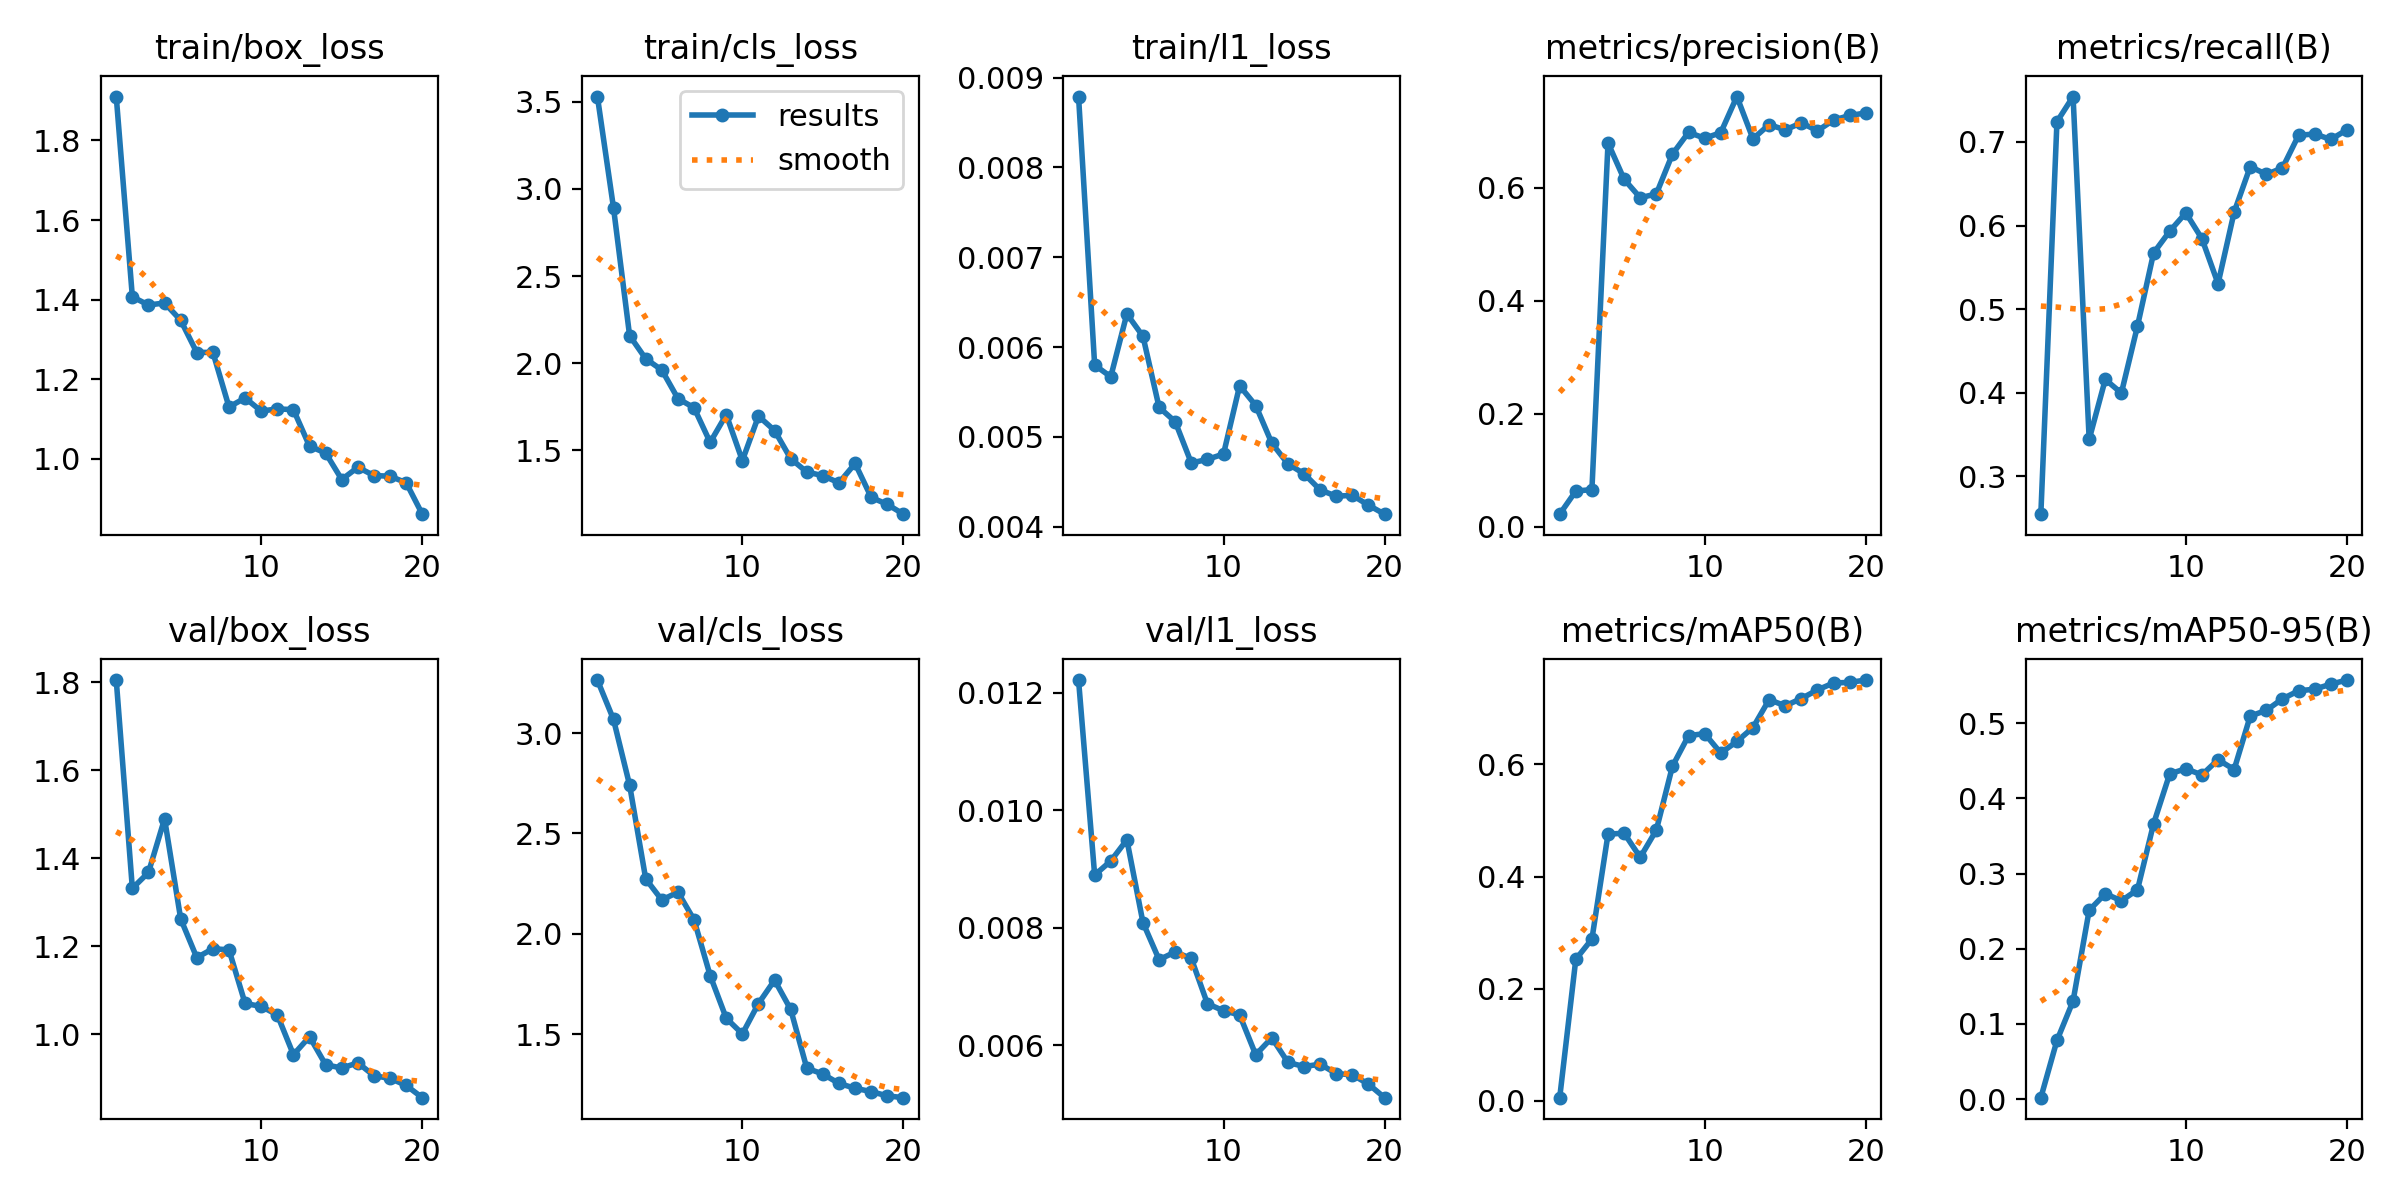

In [15]:
from IPython.display import Image, display

display(
    Image(
        filename="runs/detect/train/results.png"
    )
)